In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("aqi_india_38cols_knn_final.csv")
df.head()

,city,state,latitude,longitude,datetime,month,day_name,is_weekend,season,time_of_day,...,no2_ugm3,so2_ugm3,o3_ugm3,dust_ugm3,aod,us_aqi,aqi_category,pm25_category_india,festival_period,crop_burning_season
0,agartala,tripura,23.8315,91.2868,2022-08-05 00:00:00,8.0,friday,False,monsoon,night,...,21.8,2.7,32.0,0.0,0.14,289.0,Very Unhealthy,good,False,False
1,agartala,tripura,23.8315,91.2868,2022-08-05 01:00:00,8.0,friday,False,monsoon,night,...,18.5,3.0,33.0,0.0,0.14,289.0,Very Unhealthy,good,False,False
2,agartala,tripura,23.8315,91.2868,2022-08-05 02:00:00,8.0,friday,False,monsoon,night,...,15.1,3.3,34.0,0.0,0.15,54.0,Moderate,good,False,False
3,agartala,tripura,23.8315,91.2868,2022-08-05 03:00:00,8.0,friday,False,monsoon,night,...,14.1,3.3,32.0,0.0,0.15,54.0,Moderate,good,False,False
4,agartala,tripura,23.8315,91.2868,2022-08-05 04:00:00,8.0,friday,False,monsoon,night,...,13.9,3.2,30.0,0.0,0.14,54.0,Moderate,good,False,False


In [3]:
# Create future target (6-hour ahead AQI)
df["future_aqi_6h"] = df["us_aqi"].shift(-6)

In [4]:
df["timestamp"] = pd.to_datetime(df["datetime"])
df = df.sort_values("timestamp")

In [5]:
# Time-based features
df["month"] = df["timestamp"].dt.month
df["day_name"] = df["timestamp"].dt.day_name()
df["hour"] = df["timestamp"].dt.hour
df["is_weekend"] = df["day_name"].isin(["Saturday", "Sunday"])

In [6]:
# Lag features
lags = [1, 3, 6, 12, 24]
for lag in lags:
    df[f"aqi_lag_{lag}"] = df["us_aqi"].shift(lag)

In [7]:
# Rolling Features
df["rolling_mean_6"] = df["us_aqi"].rolling(6).mean()
df["rolling_mean_12"] = df["us_aqi"].rolling(12).mean()
df["rolling_std_12"] = df["us_aqi"].rolling(12).std()

In [8]:
# Pollutant Interactions
df["pm_ratio"] = df["pm2_5_ugm3"] / (df["pm10_ugm3"] + 1)
df["gas_sum"] = df["co_ugm3"] + df["no2_ugm3"] + df["so2_ugm3"]

In [9]:
# HANDLE MISSING VALUES
df = df.fillna(method="ffill")
df = df.dropna()

/tmp/ipykernel_10716/2841172153.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method="ffill")


In [10]:
# Final dataset check
print("Final Shape:", df.shape)
df.head()

Final Shape: (842136, 44)


,city,state,latitude,longitude,datetime,month,day_name,is_weekend,season,time_of_day,...,aqi_lag_1,aqi_lag_3,aqi_lag_6,aqi_lag_12,aqi_lag_24,rolling_mean_6,rolling_mean_12,rolling_std_12,pm_ratio,gas_sum
551760,lucknow,uttar pradesh,26.8467,80.9462,2022-08-05 00:00:00,8,Friday,False,monsoon,night,...,48.833332,107.000000,98.666664,155.666670,289.000000,109.972221,116.986111,36.597556,0.693130,600.3
145200,bhubaneswar,odisha,20.2961,85.8245,2022-08-05 00:00:00,8,Friday,False,monsoon,night,...,169.833330,72.666664,117.500000,153.000000,90.000000,114.083333,116.083333,35.752270,0.655602,351.2
232320,dehradun,uttarakhand,30.3165,78.0322,2022-08-05 00:00:00,8,Friday,False,monsoon,night,...,142.166670,48.833332,144.000000,100.333336,51.000000,108.361110,116.861110,35.478963,0.684066,729.2
609840,panaji,goa,15.4909,73.8278,2022-08-05 00:00:00,8,Friday,False,monsoon,night,...,109.666664,169.833330,107.000000,158.666670,42.833332,119.638888,118.194444,37.439368,0.559633,126.3
696960,ranchi,jharkhand,23.3441,85.3096,2022-08-05 00:00:00,8,Friday,False,monsoon,night,...,174.666670,142.166670,72.666664,96.000000,37.666668,133.777778,123.319444,38.323877,0.673239,347.5


In [11]:
df.describe()

,latitude,longitude,month,humidity_percent,dew_point_c,wind_gusts_kmh,precipitation_mm,pressure_msl_hpa,cloud_cover_percent,pm2_5_ugm3,...,aqi_lag_1,aqi_lag_3,aqi_lag_6,aqi_lag_12,aqi_lag_24,rolling_mean_6,rolling_mean_12,rolling_std_12,pm_ratio,gas_sum
count,842136.000000,842136.000000,842136.000000,842136.000000,842136.000000,842136.000000,842136.000000,842136.000000,842136.000000,842136.000000,...,842136.000000,842136.000000,842136.000000,842136.000000,842136.000000,842136.000000,842136.000000,842136.000000,842136.000000,842136.000000
mean,23.129042,82.769195,6.801619,71.324145,17.160617,19.270553,0.197794,1009.489904,50.500078,34.550208,...,94.711576,94.711413,94.711341,94.711250,94.711289,94.711505,94.711401,38.688311,0.665714,474.315705
min,8.524100,72.571400,1.000000,3.000000,-11.500000,3.200000,0.000000,979.400000,0.000000,1.900000,...,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,0.000000,0.077986,96.200000
25%,20.296100,77.173400,4.000000,58.000000,12.100000,11.500000,0.000000,1005.400000,2.000000,14.700000,...,59.000000,59.000000,59.000000,59.000000,59.000000,72.166667,73.750000,28.850188,0.597403,246.500000
50%,23.831500,80.946200,7.000000,76.000000,18.600000,17.300000,0.000000,1009.900000,47.000000,25.900000,...,84.000000,84.000000,84.000000,84.000000,84.000000,93.500000,94.750000,37.317384,0.658537,352.500000
75%,26.912400,88.606500,10.000000,89.000000,23.300000,25.200000,0.000000,1013.800000,100.000000,44.200000,...,128.000000,128.000000,128.000000,128.000000,128.000000,115.500000,114.666667,47.215175,0.691343,543.900000
max,31.104800,94.108600,12.000000,100.000000,27.300000,55.100000,51.700000,1028.100000,100.000000,183.500000,...,289.000000,289.000000,289.000000,289.000000,289.000000,221.333333,196.916667,109.013309,0.993816,3159.300000
std,5.543476,6.937195,3.411546,21.362049,7.020444,9.921463,0.915800,5.698810,43.413394,29.652265,...,47.234428,47.234333,47.234283,47.234149,47.234485,28.693241,26.188272,13.745693,0.153569,405.351525


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 842136 entries, 551760 to 842159
Data columns (total 44 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   city                 842136 non-null  object        
 1   state                842136 non-null  object        
 2   latitude             842136 non-null  float64       
 3   longitude            842136 non-null  float64       
 4   datetime             842136 non-null  object        
 5   month                842136 non-null  int32         
 6   day_name             842136 non-null  object        
 7   is_weekend           842136 non-null  bool          
 8   season               842136 non-null  object        
 9   time_of_day          842136 non-null  object        
 10  humidity_percent     842136 non-null  float64       
 11  dew_point_c          842136 non-null  float64       
 12  wind_gusts_kmh       842136 non-null  float64       
 13  precipitation_

In [13]:
df.isnull().sum()

city                   0
state                  0
latitude               0
longitude              0
datetime               0
month                  0
day_name               0
is_weekend             0
season                 0
time_of_day            0
humidity_percent       0
dew_point_c            0
wind_gusts_kmh         0
precipitation_mm       0
is_raining             0
heavy_rain             0
pressure_msl_hpa       0
cloud_cover_percent    0
pm2_5_ugm3             0
pm10_ugm3              0
co_ugm3                0
no2_ugm3               0
so2_ugm3               0
o3_ugm3                0
dust_ugm3              0
aod                    0
us_aqi                 0
aqi_category           0
pm25_category_india    0
festival_period        0
crop_burning_season    0
future_aqi_6h          0
timestamp              0
hour                   0
aqi_lag_1              0
aqi_lag_3              0
aqi_lag_6              0
aqi_lag_12             0
aqi_lag_24             0
rolling_mean_6         0


In [14]:
df.columns.tolist()

['city',
 'state',
 'latitude',
 'longitude',
 'datetime',
 'month',
 'day_name',
 'is_weekend',
 'season',
 'time_of_day',
 'humidity_percent',
 'dew_point_c',
 'wind_gusts_kmh',
 'precipitation_mm',
 'is_raining',
 'heavy_rain',
 'pressure_msl_hpa',
 'cloud_cover_percent',
 'pm2_5_ugm3',
 'pm10_ugm3',
 'co_ugm3',
 'no2_ugm3',
 'so2_ugm3',
 'o3_ugm3',
 'dust_ugm3',
 'aod',
 'us_aqi',
 'aqi_category',
 'pm25_category_india',
 'festival_period',
 'crop_burning_season',
 'future_aqi_6h',
 'timestamp',
 'hour',
 'aqi_lag_1',
 'aqi_lag_3',
 'aqi_lag_6',
 'aqi_lag_12',
 'aqi_lag_24',
 'rolling_mean_6',
 'rolling_mean_12',
 'rolling_std_12',
 'pm_ratio',
 'gas_sum']

In [42]:
df.to_csv("aqi.csv", index=False)

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [16]:
# Drop unnecessary columns
drop_cols = [
    "datetime",
    "city",
    "state",
    "timestamp",
    "aqi_category",
    "pm25_category_india",
    "future_aqi_6h"
]

In [17]:
X = df.drop(columns=drop_cols)
y = df["future_aqi_6h"]

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [19]:
categorical_cols = X.select_dtypes(include=["object"]).columns
boolean_cols = X.select_dtypes(include=["bool"]).columns
numeric_cols = X.select_dtypes(include=["int32","float64"]).columns

In [20]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown='ignore', max_categories=10), categorical_cols),
        ("bool", "passthrough", boolean_cols)
    ]
)

In [21]:
lr = LinearRegression()
model_lr = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("LinearRegression", lr)
])

In [22]:
# Time-Series Train/Test Split
split_date = "2025-01-01"

train = df[df["timestamp"] < split_date]
test  = df[df["timestamp"] >= split_date]

X_train = train.drop(columns=drop_cols)
y_train = train["future_aqi_6h"]

X_test = test.drop(columns=drop_cols)
y_test = test["future_aqi_6h"]

In [23]:
model_lr.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('LinearRegression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [24]:
y_pred_lr = model_lr.predict(X_test)
mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
r2 = r2_score(y_test, y_pred_lr)
print("MAE:", mae)
print("MSE:", mse)
print("R2:", r2)

MAE: 8.454832400987605
MSE: 185.75976322214132
R2: 0.9282305873173923


In [25]:
print("Training score:", model_lr.score(X_train, y_train))
print("Testing score:", model_lr.score(X_test, y_test))

Training score: 0.9386511768316506
Testing score: 0.9282305873173923


In [26]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)
model_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("Rf-regressor", rf)
])

In [27]:
model_rf.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('Rf-regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [28]:
y_pred_rf = model_rf.predict(X_test)
mae = mean_absolute_error(y_test, y_pred_rf)
mse = mean_squared_error(y_test, y_pred_rf)
r2 = r2_score(y_test, y_pred_rf)
print("MAE:", mae)
print("MSE:", mse)
print("R2:", r2)

MAE: 9.948399190101773
MSE: 283.3551353768341
R2: 0.8905240225663023


In [29]:
print("Training score:", model_rf.score(X_train, y_train))
print("Testing score:", model_rf.score(X_test, y_test))

Training score: 0.9484293092517255
Testing score: 0.8905240225663023


In [31]:
!pip install lightgbm

  Using cached lightgbm-4.6.0-py3-none-manylinux_2_28_x86_64.whl.metadata (17 kB)
Using cached lightgbm-4.6.0-py3-none-manylinux_2_28_x86_64.whl (3.6 MB)


In [32]:
import lightgbm as lgb

In [33]:
lgbm = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=-1,
    num_leaves=128,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
model_lgbm = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("LGBM", lgbm)
])

In [34]:
model_lgbm.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.091112 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5767
[LightGBM] [Info] Number of data points in the train set: 612456, number of used features: 51
[LightGBM] [Info] Start training from score 93.278516


,steps,"[('preprocessor', ...), ('LGBM', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [35]:
y_pred_lgbm = model_lgbm.predict(X_test)
mae = mean_absolute_error(y_test, y_pred_lgbm)
mse = mean_squared_error(y_test, y_pred_lgbm)
r2 = r2_score(y_test, y_pred_lgbm)
print("MAE:", mae)
print("MSE:", mse)
print("R2:", r2)

/home/avneesh/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


MAE: 4.746407617971836
MSE: 64.79234890582666
R2: 0.9749670825014084


In [36]:
print("Training score:", model_lgbm.score(X_train, y_train))
print("Testing score:", model_lgbm.score(X_test, y_test))

/home/avneesh/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Training score: 0.9905985817079117


/home/avneesh/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Testing score: 0.9749670825014084


In [37]:
from xgboost import XGBRegressor
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
model_xgb = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("XGB", xgb)
])

In [38]:
model_xgb.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('XGB', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [39]:
y_pred_xgb = model_xgb.predict(X_test)
mae = mean_absolute_error(y_test, y_pred_xgb)
mse = mean_squared_error(y_test, y_pred_xgb)
r2 = r2_score(y_test, y_pred_xgb)
print("MAE:", mae)
print("MSE:", mse)
print("R2:", r2)

MAE: 4.846250529460893
MSE: 70.44738496657848
R2: 0.9727822249750032


In [40]:
print("Training score:", model_xgb.score(X_train, y_train))
print("Testing score:", model_xgb.score(X_test, y_test))

Training score: 0.9900197757293103
Testing score: 0.9727822249750032


In [41]:
# Take sample predictions
sample_df = pd.DataFrame({
    "Actual": y_test.values[:20],
    "Predicted": y_pred_lgbm[:20]
})

print(sample_df)

    Actual   Predicted
0    167.0  166.627051
1    123.0  118.787836
2    170.0  173.270445
3     92.0   90.637123
4    103.0  102.875012
5    160.0  160.485760
6    204.0  205.102156
7    162.0  161.039267
8    152.0  147.847093
9    161.0  160.567224
10    89.0   94.310764
11   171.0  171.336733
12   120.0  112.236042
13    84.0   85.431100
14   129.0  126.280693
15   107.0  115.853796
16   104.0  110.535446
17   201.0  203.120956
18   161.0  158.918550
19    76.0   76.284577


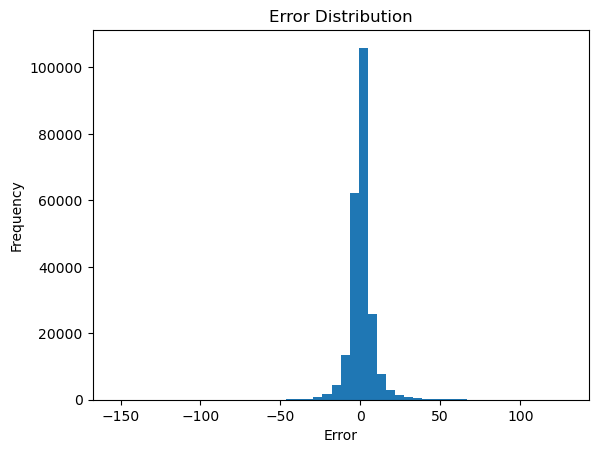

In [41]:
import matplotlib.pyplot as plt

errors = y_test - y_pred_lgbm

plt.hist(errors, bins=50)
plt.title("Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

In [42]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_lgbm
})

results["Abs_Error"] = abs(results["Actual"] - results["Predicted"])

print(results["Abs_Error"].describe())

count    229680.000000
mean          4.741792
std           6.474518
min           0.000035
25%           1.237289
50%           2.803273
75%           5.716163
max         153.402838
Name: Abs_Error, dtype: float64


In [43]:
worst_cases = results.sort_values("Abs_Error", ascending=False).head(10)
print(worst_cases)

        Actual   Predicted   Abs_Error
290399    36.0  189.402838  153.402838
346127   136.0  281.913033  145.913033
58079     25.0  170.648977  145.648977
348479    52.0  193.119343  141.119343
609839    28.0  165.173839  137.173839
345791   289.0  160.398551  128.601449
290398    59.5  186.567958  127.067958
345876   289.0  163.707896  125.292104
345790   289.0  168.009647  120.990353
345875   289.0  168.238913  120.761087


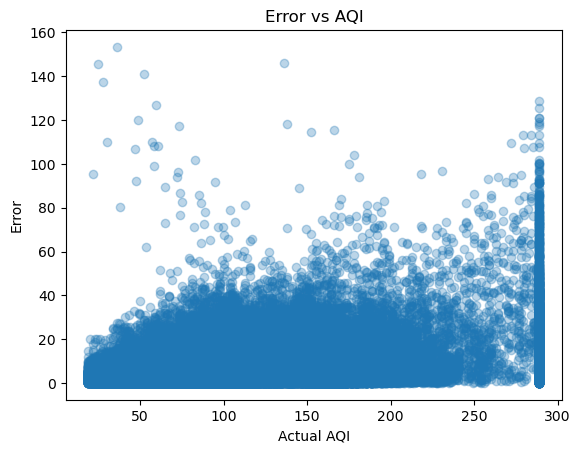

In [44]:
plt.scatter(results["Actual"], results["Abs_Error"], alpha=0.3)
plt.xlabel("Actual AQI")
plt.ylabel("Error")
plt.title("Error vs AQI")
plt.show()

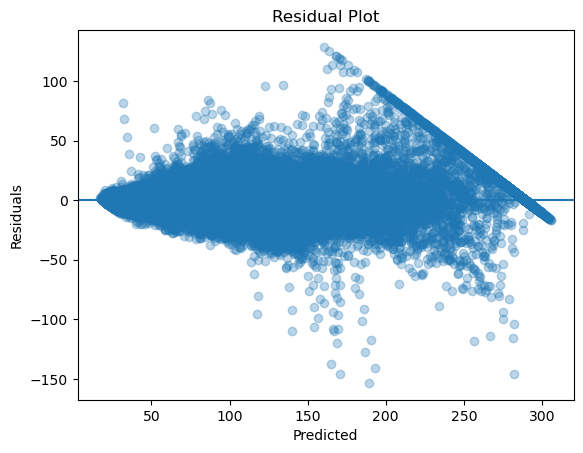

In [45]:
plt.scatter(y_pred_lgbm, y_test - y_pred_lgbm, alpha=0.3)
plt.axhline(y=0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

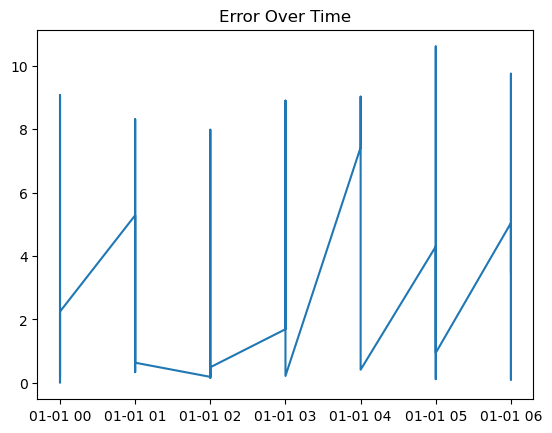

In [46]:
results["timestamp"] = test["timestamp"].values

plt.plot(results["timestamp"][:200], results["Abs_Error"][:200])
plt.title("Error Over Time")
plt.show()

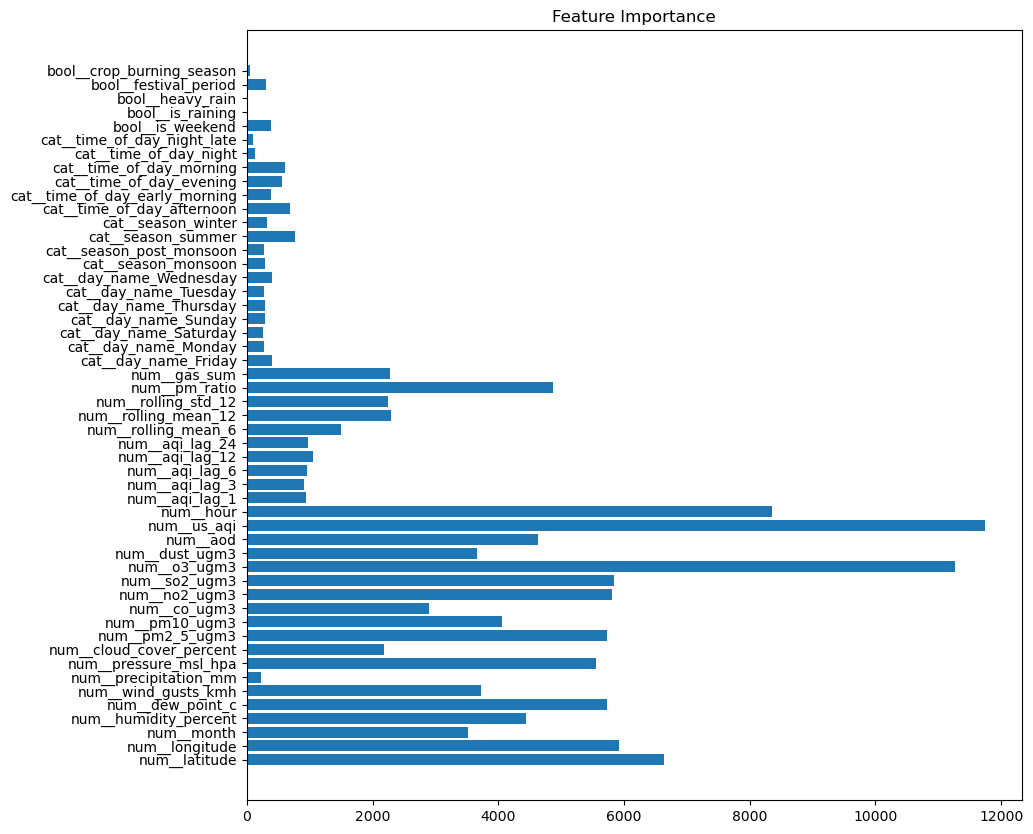

In [47]:
import matplotlib.pyplot as plt

lgbm_model = model_lgbm.named_steps["LGBM"]
importance = lgbm_model.feature_importances_
feature_names = model_lgbm.named_steps["preprocessor"].get_feature_names_out()

plt.figure(figsize=(10, 10))
plt.barh(feature_names, importance)
plt.title("Feature Importance")
plt.show()

In [48]:
import pandas as pd

feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(feat_imp.head(15))

                  Feature  Importance
17            num__us_aqi       11742
14           num__o3_ugm3       11265
18              num__hour        8360
0           num__latitude        6633
1          num__longitude        5923
13          num__so2_ugm3        5847
12          num__no2_ugm3        5812
4        num__dew_point_c        5735
9         num__pm2_5_ugm3        5728
7   num__pressure_msl_hpa        5547
27          num__pm_ratio        4868
16               num__aod        4639
3   num__humidity_percent        4445
10         num__pm10_ugm3        4066
5     num__wind_gusts_kmh        3719


In [129]:
import joblib

joblib.dump(model_lgbm, "aqi_model.pkl")

['aqi_model.pkl']

In [49]:
print(X_train.shape)

(612456, 37)


In [50]:
print(X_train.columns.tolist())

['latitude', 'longitude', 'month', 'day_name', 'is_weekend', 'season', 'time_of_day', 'humidity_percent', 'dew_point_c', 'wind_gusts_kmh', 'precipitation_mm', 'is_raining', 'heavy_rain', 'pressure_msl_hpa', 'cloud_cover_percent', 'pm2_5_ugm3', 'pm10_ugm3', 'co_ugm3', 'no2_ugm3', 'so2_ugm3', 'o3_ugm3', 'dust_ugm3', 'aod', 'us_aqi', 'festival_period', 'crop_burning_season', 'hour', 'aqi_lag_1', 'aqi_lag_3', 'aqi_lag_6', 'aqi_lag_12', 'aqi_lag_24', 'rolling_mean_6', 'rolling_mean_12', 'rolling_std_12', 'pm_ratio', 'gas_sum']


In [54]:
mumbai_data = df[
    (df["state"] == 'maharashtra') &
    (df["city"] == 'mumbai')
]

print(mumbai_data.head())

          city        state  latitude  longitude             datetime  month  \
580801  mumbai  maharashtra    19.076    72.8777  2022-08-05 01:00:00      8   
580802  mumbai  maharashtra    19.076    72.8777  2022-08-05 02:00:00      8   
580803  mumbai  maharashtra    19.076    72.8777  2022-08-05 03:00:00      8   
580804  mumbai  maharashtra    19.076    72.8777  2022-08-05 04:00:00      8   
580805  mumbai  maharashtra    19.076    72.8777  2022-08-05 05:00:00      8   

       day_name  is_weekend   season time_of_day  ...   aqi_lag_1   aqi_lag_3  \
580801   Friday       False  monsoon       night  ...   63.666668  100.000000   
580802   Friday       False  monsoon       night  ...  109.000000   96.500000   
580803   Friday       False  monsoon       night  ...   57.000000   65.666664   
580804   Friday       False  monsoon       night  ...   54.000000   86.666664   
580805   Friday       False  monsoon       night  ...   61.000000   58.000000   

         aqi_lag_6  aqi_lag_12  

In [60]:
sample_input = {
    'latitude': 19.0760,
    'longitude': 72.8777,
    'month': 4,
    'day_name': 'Tuesday',
    'is_weekend': 0,
    'season': 'summer',
    'time_of_day': 'afternoon',
    'humidity_percent': 65.0,
    'dew_point_c': 24.0,
    'wind_gusts_kmh': 18.5,
    'precipitation_mm': 0.0,
    'is_raining': 0,
    'heavy_rain': 0,
    'pressure_msl_hpa': 1012.0,
    'cloud_cover_percent': 40.0,
    'pm2_5_ugm3': 110.0,
    'pm10_ugm3': 180.0,
    'co_ugm3': 900.0,
    'no2_ugm3': 45.0,
    'so2_ugm3': 12.0,
    'o3_ugm3': 30.0,
    'dust_ugm3': 70.0,
    'aod': 0.6,
    'us_aqi': 160,
    'festival_period': 0,
    'crop_burning_season': 0,
    'hour': 14,
    'aqi_lag_1': 150,
    'aqi_lag_3': 145,
    'aqi_lag_6': 140,
    'aqi_lag_12': 135,
    'aqi_lag_24': 130,
    'rolling_mean_6': 142.0,
    'rolling_mean_12': 138.0,
    'rolling_std_12': 6.5,
    'pm_ratio': 110.0 / 180.0,
    'gas_sum': 900.0 + 45.0 + 12.0 + 30.0
}

In [62]:
feature_columns = X_train.columns.tolist()
input_df = pd.DataFrame([sample_input])
input_df = input_df[feature_columns]  # ensure correct order

In [64]:
prediction = model_lgbm.predict(input_df)[0]
print("Predicted AQI (6h ahead):", prediction)

Predicted AQI (6h ahead): 181.64407385420512


/home/avneesh/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [66]:
import joblib
feature_columns = X_train.columns.tolist()
joblib.dump(feature_columns, "features.pkl")

['features.pkl']